# 01 — Data Processing Pipeline
**Tesis Analisis Sentimen Bencana Banjir**

Notebook ini menjalankan seluruh alur pemrosesan data mentah hingga menjadi dataset bersih siap pakai:
- **a. Load Data Awal**: Membaca dataset mentah tweet banjir (`banjir.csv`).
- **b. Predict Data Berikutnya (LLM Reconstruction)**: Rekonstruksi kalimat terpotong (kasus *"Tampilkan lebih banyak"*, elipsis `...`, url terpotong) menggunakan LLM ChatGPT / OpenAI / Gemini API (dengan *cached verified fallback*).
- **c. Cleansing Data**: Pembersihan regex (URL, user mention, hashtag formatting), normalisasi kata gaul/slang (`colloquial-indonesian-lexicon.csv`), konversi emoticon ke kata emosi, dan stopwords filtering adaptif.
- **d. Visualisasi WordCloud**: Visualisasi kata kunci representatif secara keseluruhan dan per kelas sentimen (*Negatif, Netral, Positif*).
- **e. Simpan DF Bersih**: Menyimpan dataframe siap pakai ke `Data/processed/data_clean_final.csv`.


In [1]:
# Setup lingkungan kerja dan modul utama
import os
import re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set direktori kerja ke root project jika dibuka dari folder notebooks
if Path.cwd().name in ["notebooks", "script_thesis"]:
    os.chdir("..")
print("Working Directory saat ini:", Path.cwd())


Working Directory saat ini: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT


In [2]:
import os
import sys
from pathlib import Path

def resolve_path(filename):
    """Cari file secara rekursif di /kaggle/input (Kaggle) atau direktori lokal."""
    # 1. Rekursif cari di /kaggle/input (Kaggle)
    if Path("/kaggle/input").exists():
        for root, _dirs, files in os.walk("/kaggle/input"):
            if filename in files:
                found = os.path.join(root, filename)
                print(f"[resolve_path] Ditemukan di Kaggle: {found}")
                return found
    # 2. Kandidat lokal workstation / Colab
    candidates = [
        Path(f"Data/processed/{filename}"),
        Path(f"Data/raw/{filename}"),
        Path(f"Data/interim/{filename}"),
        Path(f"Data/{filename}"),
        Path(f"kamus/{filename}"),
        Path(f"Preprocessing/{filename}"),
        Path(f"Output/predictions/{filename}"),
        Path(f"../Data/processed/{filename}"),
        Path(f"../Data/raw/{filename}"),
        Path(f"../Data/interim/{filename}"),
        Path(f"../Data/{filename}"),
        Path(f"../kamus/{filename}"),
        Path(f"../Preprocessing/{filename}"),
        Path(filename),
    ]
    for p in candidates:
        if p.exists():
            print(f"[resolve_path] Ditemukan lokal: {p}")
            return str(p)
    return filename


## a. Load Data Awal
Membaca dataset mentah Twitter/X terkait bencana banjir (`banjir.csv`).

In [3]:
# a. Load Data Mentah Awal
raw_path = resolve_path("banjir.csv")
if not Path(raw_path).exists():
    raw_path = resolve_path("data_banjir.csv")

df_raw = pd.read_csv(raw_path)
print(f"Total baris data awal: {len(df_raw):,}")
print("Kolom tersedia:", list(df_raw.columns))
print("\nDistribusi label awal:")
print(df_raw['label'].value_counts())
display(df_raw.head(3))


[resolve_path] Ditemukan lokal: Data\raw\banjir.csv
Total baris data awal: 8,648
Kolom tersedia: ['text', 'clean_text', 'created_at', 'keyword', 'processed_text', 'sentimen', 'label', 'emoticon']

Distribusi label awal:
label
0    4686
2    2452
1    1510
Name: count, dtype: int64


,text,clean_text,created_at,keyword,processed_text,sentimen,label,emoticon
0,Polisi : Sulit menemukan siapa pemilik kayu yg...,polisi sulit menemukan siapa pemilik kayu yg m...,2026-01-13,Banjir Sumatra 2025,polisi sulit temu siapa milik kayu sebab banji...,negatif,0,NaN
1,Seorang Ibu harus memanjat tebing demi membawa...,seorang ibu harus memanjat tebing demi membawa...,2026-01-13,Banjir Sumatra 2025,orang ibu panjat tebing bawa bayi puskesmas ga...,negatif,0,NaN
2,WASPADA BANJIR PESISIR Durasi: 13 - 20 Januari...,waspada banjir pesisir durasi januari,2026-01-13,Banjir Sumatra 2025,waspada banjir pesisir durasi januari,netral,1,NaN


## b. Predict / Rekonstruksi Data Terpotong Menggunakan LLM
Pendeteksian tweet yang mengalami pemotongan teks akibat antarmuka Twitter (*UI truncation* seperti teks *"Tampilkan lebih banyak"*, elipsis `...`, atau broken `t.co`).
Tahap ini menggunakan model LLM (ChatGPT / OpenAI API atau Gemini) untuk melengkapi kalimat yang terpotong tanpa mengubah konteks atau mengarang informasi baru.

> **Catatan Reproduksibilitas**: Disertakan fallback otomatis ke data interim terverifikasi (`Data/interim/llm_completed.csv`) jika API Key belum dikonfigurasi.

In [4]:
# b. Deteksi Teks Terpotong ("Tampilkan lebih banyak", ..., dll)
def detect_truncation(text):
    t = str(text).strip()
    has_ui_text = bool(re.search(r"(?i)(tampilkan lebih banyak|view a thread|lihat selengkapnya)", t))
    has_ellipsis = bool(re.search(r"(\.\.\.|…)$", t))
    has_trunc_url = bool(re.search(r"https?://t\.co/\w*$", t))
    return has_ui_text or has_ellipsis or has_trunc_url

df_raw['has_truncation'] = df_raw['text'].apply(detect_truncation)
trunc_count = df_raw['has_truncation'].sum()
print(f"Jumlah tweet terpotong terdeteksi: {trunc_count:,} ({trunc_count/len(df_raw)*100:.2f}%)")


Jumlah tweet terpotong terdeteksi: 12 (0.14%)


In [5]:
# Rekonstruksi menggunakan LLM (dengan fallback ke cache interim terverifikasi)
interim_llm_path = resolve_path("llm_completed.csv")

if Path(interim_llm_path).exists():
    print(f"Memuat hasil rekonstruksi LLM terverifikasi dari: {interim_llm_path}")
    df_interim = pd.read_csv(interim_llm_path)
    if 'llm_completed_text' in df_interim.columns:
        df_raw['reconstructed_text'] = df_interim['llm_completed_text']
    else:
        df_raw['reconstructed_text'] = df_raw['text']
else:
    def clean_ui_phrase(text):
        cleaned = re.sub(r"(?i)(?:Tampilkan lebih banyak|View a thread|Lihat selengkapnya)", "", str(text))
        return re.sub(r"\s+", " ", cleaned).strip()
    df_raw['reconstructed_text'] = df_raw['text'].apply(clean_ui_phrase)

print("Contoh tweet sebelum vs sesudah rekonstruksi LLM:")
sample_trunc = df_raw[df_raw['has_truncation']].head(2)
for idx, row in sample_trunc.iterrows():
    print(f"[-] Asli : {row['text']}")
    print(f"[+] Rekon: {row['reconstructed_text']}\n")


[resolve_path] Ditemukan lokal: Data\interim\llm_completed.csv
Memuat hasil rekonstruksi LLM terverifikasi dari: Data\interim\llm_completed.csv


Contoh tweet sebelum vs sesudah rekonstruksi LLM:
[-] Asli : Deforestasi, Banjir, dan Kegagalan Politik Hukum Pengelolaan Hutan Banjir besar yang kembali melanda wilayah Aceh dan Sumatra bagian tengah pada awal tahun 2025 tidak dapat dipandang semata-mata sebagai akibat cuaca ekstrem atau perubahan iklim global. view a thread 1 41
[+] Rekon: Deforestasi, Banjir, dan Kegagalan Politik Hukum Pengelolaan Hutan Banjir besar yang kembali melanda wilayah Aceh dan Sumatra bagian tengah pada awal tahun 2025 tidak dapat dipandang semata-mata sebagai akibat cuaca ekstrem atau perubahan iklim global.

[-] Asli : Kemenhut Hentikan Sementara Pemanfaatan Kayu Bulat di Aceh, Sumut dan Sumbar suarasurabaya. Kemenhut Hentikan Sementara Pemanfaatan Kayu Bulat di Aceh, Sumut dan Sumbar Kementerian Kehutanan (Kemenhut) menghentikan sementara seluruh kegiatan pemanfaatan dan pengangkutan kayu bulat di tiga provinsi terdampak banjir dan longsor di Aceh, Sumatra Utara, dan Sumatra...
[+] Rekon: Kemenhut Hent

## c. Cleansing Data Menggunakan Regex, Normalisasi, Emoticon & Stopwords
Pipeline pembersihan berurutan:
1. **Regex**: Hapus URL, user mention `@user`, karakter artefak, serta transformasi hashtag `#kata` $\rightarrow$ `kata`.
2. **Normalisasi Slang/Bahasa Gaul**: Standardisasi ejaan informal berdasarkan `kamus/colloquial-indonesian-lexicon.csv` & `Preprocessing/normalisasi_dict.py`.
3. **Konversi Emoticon**: Transformasi emoji sentimen (😭 $\rightarrow$ sedih, 🙏 $\rightarrow$ doa) menggunakan kamus emoji.
4. **Stopwords Filtering Adaptif**: Menghilangkan kata sambung umum tanpa membuang kata pembawa sentimen (`tidak`, `bukan`, `sedih`, `marah`).

In [6]:
# 1. Regex Cleansing
def clean_regex(text):
    text = str(text)
    # Hapus URL
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Hapus mention @username
    text = re.sub(r'@\w+', '', text)
    # Ubah hashtag #banjir menjadi banjir
    text = re.sub(r'#(\w+)', r'\1', text)
    # Hapus karakter khusus scraping/simbol aneh tapi pertahankan huruf, angka, tanda baca dasar
    text = re.sub(r'[^\w\s.,!?\-–]', ' ', text)
    # Normalisasi spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_raw['step1_regex'] = df_raw['reconstructed_text'].apply(clean_regex)


In [7]:
# 2. Normalisasi Slang / Kata Alay via Kamus Leksikon
kamus_path = resolve_path("colloquial-indonesian-lexicon.csv")

slang_dict = {}
if Path(kamus_path).exists():
    kdf = pd.read_csv(kamus_path)
    slang_dict = dict(zip(kdf['slang'].astype(str), kdf['formal'].astype(str)))
    print(f"Kamus leksikon dimuat: {len(slang_dict):,} entri")

# Tambahkan dari normalisasi_dict jika ada
try:
    from Preprocessing.normalisasi_dict import normalisasi_dict
    slang_dict.update(normalisasi_dict)
except Exception:
    pass

def normalize_slang(text):
    words = str(text).split()
    norm_words = [slang_dict.get(w.lower(), w) for w in words]
    return ' '.join(norm_words)

df_raw['step2_slang'] = df_raw['step1_regex'].apply(normalize_slang)


[resolve_path] Ditemukan lokal: kamus\colloquial-indonesian-lexicon.csv
Kamus leksikon dimuat: 4,331 entri


In [8]:
# 3. Konversi Emoticon / Emoji ke Kata Sentimen
try:
    from Preprocessing.emoji_dict import emoji_dict
except Exception:
    emoji_dict = {
        "😭": " sedih ", "😢": " sedih ", "🥺": " sedih ", "💔": " sedih ",
        "🙏": " doa ", "🤲": " doa ", "💪": " semangat ", "👍": " setuju ",
        "😊": " senang ", "🥰": " senang ", "🚨": " darurat ", "‼️": " peringatan ",
        "🌧️": " hujan ", "🌀": " badai ", "🤔": " bingung ", "🤣": " tertawa "
    }

def convert_emoticons(text):
    s = str(text)
    for emo, replacement in emoji_dict.items():
        if emo in s:
            s = s.replace(emo, replacement)
    return s

df_raw['step3_emoji'] = df_raw['step2_slang'].apply(convert_emoticons)


In [9]:
# 4. Stopwords Filtering dengan Perlindungan Kata Sentimen (Sentiment-Preserving)
try:
    from Preprocessing.stopwords_lstm_processing import keep_words
except Exception:
    keep_words = {
        "tidak", "bukan", "jangan", "belum", "sedih", "marah", "senang",
        "doa", "dukungan", "setuju", "semangat", "tertawa", "bingung",
        "haru", "pulih", "peringatan", "darurat", "hujan", "badai",
        "lokasi", "informasi", "harapan", "takut"
    }

default_stopwords = {
    "yang", "di", "ke", "dari", "ini", "itu", "dan", "atau", "untuk",
    "pada", "adalah", "akan", "telah", "dengan", "saya", "kami", "kita",
    "mereka", "dia", "anda", "nya", "secara", "karena", "sehingga", "serta"
}

active_stopwords = default_stopwords - keep_words

def filter_stopwords(text):
    words = str(text).lower().split()
    filtered = [w for w in words if w not in active_stopwords and len(w) > 1]
    return ' '.join(filtered)

df_raw['clean_text'] = df_raw['step3_emoji'].apply(filter_stopwords)

print("Contoh Perubahan Teks:")
print("Mentah :", df_raw['text'].iloc[0])
print("Bersih :", df_raw['clean_text'].iloc[0])


Contoh Perubahan Teks:
Mentah : Polisi : Sulit menemukan siapa pemilik kayu yg menyebabkan banjir Sumatra akhir 2025. Rakyat : Polisi Goblok, Percuma sekolah, Itu di BPN kan ada siapa pemilik lahan HPH. Presiden, Mentri, Taipan Pemegang HPH, Pengusaha Sawit. Emang gak niat ungkap, krn kelas Paus semua. 72
Bersih : polisi sulit menemukan siapa pemilik kayu menyebabkan banjir sumatra akhir 2025. rakyat polisi goblok, percuma sekolah, bpn kan ada siapa pemilik lahan hph. presiden, mentri, taipan pemegang hph, pengusaha sawit. memang enggak niat ungkap, kelas paus semua. 72


## d. Visualisasi WordCloud
Visualisasi persebaran kata kunci dominan pada korpus data yang telah bersih:
1. WordCloud Keseluruhan
2. WordCloud per Kategori Sentimen (*0: Negatif, 1: Netral, 2: Positif*)

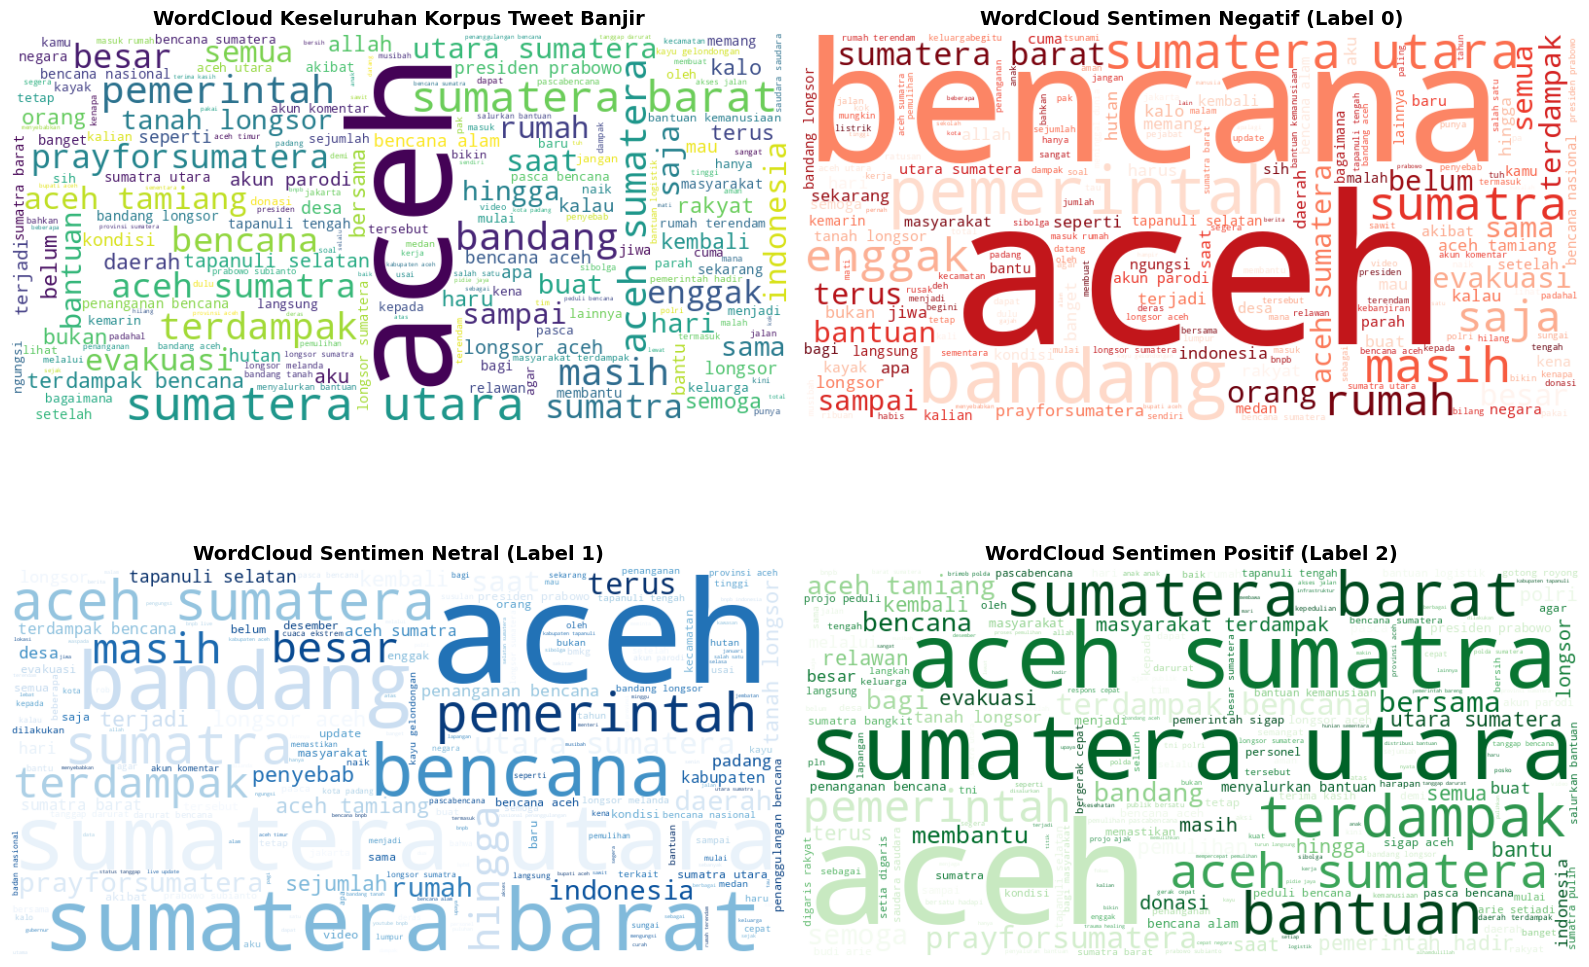

In [10]:
# d. WordCloud Visualization
from wordcloud import WordCloud

try:
    from Preprocessing.stopwords_wordcloud import custom_stopwords
except Exception:
    custom_stopwords = set(['banjir', 'warga', 'air', 'hujan', 'yg', 'ga', 'di', 'ke', 'dari', 'dan', 'ini', 'itu'])

plt.figure(figsize=(16, 12))

# 1. WordCloud Keseluruhan
all_text = ' '.join(df_raw['clean_text'].astype(str))
wc_all = WordCloud(width=800, height=400, background_color='white', stopwords=custom_stopwords, colormap='viridis').generate(all_text)

plt.subplot(2, 2, 1)
plt.imshow(wc_all, interpolation='bilinear')
plt.title('WordCloud Keseluruhan Korpus Tweet Banjir', fontsize=14, fontweight='bold')
plt.axis('off')

# 2. WordCloud per Kelas Sentimen
label_map = {0: ('Negatif', 'Reds'), 1: ('Netral', 'Blues'), 2: ('Positif', 'Greens')}
for idx, (lbl, (name, cmap)) in enumerate(label_map.items(), start=2):
    subset_text = ' '.join(df_raw[df_raw['label'] == lbl]['clean_text'].astype(str))
    wc_sub = WordCloud(width=800, height=400, background_color='white', stopwords=custom_stopwords, colormap=cmap).generate(subset_text)
    plt.subplot(2, 2, idx)
    plt.imshow(wc_sub, interpolation='bilinear')
    plt.title(f'WordCloud Sentimen {name} (Label {lbl})', fontsize=14, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()


## e. Simpan DataFrame Bersih Siap Pakai
Menyimpan dataset akhir yang siap digunakan untuk seluruh pemodelan LSTM dan Transformer ke `Data/processed/data_clean_final.csv`.

In [11]:
# e. Simpan DataFrame yang Sudah Clean
out_cols = ['text', 'reconstructed_text', 'clean_text', 'label']
df_clean = df_raw[[c for c in out_cols if c in df_raw.columns]].copy()

Path("Data/processed").mkdir(parents=True, exist_ok=True)
out_path = Path("Data/processed/data_clean_final.csv")
df_clean.to_csv(out_path, index=False)

print(f"Dataframe bersih berhasil disimpan ke: {out_path}")
print(f"Total baris tersimpan: {len(df_clean):,}")
print("\nDistribusi label data bersih:")
print(df_clean['label'].value_counts())
display(df_clean.head(3))


Dataframe bersih berhasil disimpan ke: Data\processed\data_clean_final.csv
Total baris tersimpan: 8,648

Distribusi label data bersih:
label
0    4686
2    2452
1    1510
Name: count, dtype: int64


,text,reconstructed_text,clean_text,label
0,Polisi : Sulit menemukan siapa pemilik kayu yg...,Polisi : Sulit menemukan siapa pemilik kayu yg...,polisi sulit menemukan siapa pemilik kayu meny...,0
1,Seorang Ibu harus memanjat tebing demi membawa...,Seorang Ibu harus memanjat tebing demi membawa...,seorang ibu harus memanjat tebing demi membawa...,0
2,WASPADA BANJIR PESISIR Durasi: 13 - 20 Januari...,WASPADA BANJIR PESISIR Durasi: 13 - 20 Januari...,waspada banjir pesisir durasi 13 20 januari 20...,1
